In [12]:
# importing libraries 

from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict

In [13]:
from typing import Annotated # annotate the AI messages and Human Messages {Type of list [list of messages]}
from langgraph.graph.message import add_messages # add annotated messages -> which is called reducers

In [14]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [15]:
import os

from dotenv import load_dotenv
load_dotenv()

GROQ_API=os.getenv('GROQ_API_KEY')

In [16]:
from langchain_groq import ChatGroq

llm=ChatGroq(model='llama-3.1-8b-instant')
llm.invoke("Hi my name is sandeep and I like cricket")

AIMessage(content="Hello Sandeep.  Nice to chat with a cricket enthusiast. What's your favorite aspect of cricket? Are you more into international cricket, IPL, or local cricket leagues?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 46, 'total_tokens': 83, 'completion_time': 0.070784525, 'completion_tokens_details': None, 'prompt_time': 0.002147056, 'prompt_tokens_details': None, 'queue_time': 0.048640904, 'total_time': 0.072931581}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f3db4-5347-7b63-b5b7-1173720d4311-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 37, 'total_tokens': 83})

In [17]:
def superbot(state: State):
    return {'messages': [llm.invoke(state['messages'])]} # previous messages will be appended..

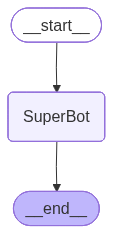

In [18]:
graph=StateGraph(State)

# adding node
graph.add_node('SuperBot', superbot)

# adding edge
graph.add_edge(START, 'SuperBot')
graph.add_edge('SuperBot', END)

graph_builder=graph.compile()

# Display
from IPython.display import display, Image

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [20]:
# Graph Invocation

graph_builder.invoke({'messages': "Hi my name is sandeep and I like cricket"})

{'messages': [HumanMessage(content='Hi my name is sandeep and I like cricket', additional_kwargs={}, response_metadata={}, id='6f925b76-e672-4ed4-b667-ba59bd8a97f5'),
  AIMessage(content="Nice to meet you, Sandeep. Cricket is a fantastic sport, and I'm happy to chat with you about it. Are you a fan of any particular team or player? Do you have a favorite format of the game, such as Test cricket, One-Day Internationals (ODIs), or Twenty20 (T20) cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 46, 'total_tokens': 117, 'completion_time': 0.085046373, 'completion_tokens_details': None, 'prompt_time': 0.002333644, 'prompt_tokens_details': None, 'queue_time': 0.049049006, 'total_time': 0.087380017}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f3db4-7b23-7233-aec6-1a23581a48d1-0', tool_ca

In [24]:
# Streaming the responses

for event in graph_builder.stream({"messages": "Hello my name is sandeep"}, stream_mode='values'): # updates -> recent messages
    print(event)

{'messages': [HumanMessage(content='Hello my name is sandeep', additional_kwargs={}, response_metadata={}, id='06a90c93-e7f4-4899-9717-ff885e4f5357')]}
{'messages': [HumanMessage(content='Hello my name is sandeep', additional_kwargs={}, response_metadata={}, id='06a90c93-e7f4-4899-9717-ff885e4f5357'), AIMessage(content="Hello Sandeep, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 42, 'total_tokens': 70, 'completion_time': 0.027667352, 'completion_tokens_details': None, 'prompt_time': 0.002362633, 'prompt_tokens_details': None, 'queue_time': 0.048200477, 'total_time': 0.030029985}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f3db8-cd9f-7823-9c75-82fa03874ec8-0', tool_calls=[], invalid_tool_calls=[], u